# 04. Forward dan Backward Chaining untuk Propositional Logic

Pada Notebook 03 kita sudah mempelajari **propositional logic** sebagai bahasa
untuk menulis pengetahuan. Kita sudah bisa membuat proposition symbol, menyusun
sentence dengan logical connective, dan menentukan truth value melalui truth
table.

Namun, sentence yang tersimpan di dalam knowledge base tidak menghasilkan
kesimpulan dengan sendirinya. Setelah mempunyai **knowledge base (KB)** dan
sebuah **query** atau pertanyaan, kita masih memerlukan cara untuk menjawab:

$$KB \vDash query\;?$$

Pertanyaan tersebut disebut **logical entailment**: apakah query pasti benar di
setiap keadaan yang membuat KB benar?

Secara umum, ada dua pendekatan untuk memeriksa entailment:

1. **Model checking** memeriksa kemungkinan model. Pendekatan ini melihat
   truth value KB dan query pada setiap model yang relevan.
2. **Theorem proving** membangun **proof** atau urutan langkah pembuktian dengan
   memakai **inference rule**, tanpa mengenumerasi seluruh model.

Notebook ini berfokus pada theorem proving. Untuk KB berbentuk khusus, yaitu
**Horn clause**, proof dapat dicari dengan dua arah:

- **forward chaining**: mulai dari fact yang diketahui, lalu bergerak menuju
  query;
- **backward chaining**: mulai dari query, lalu mencari fact yang dapat
  mendukungnya.

Alur materi notebook ini adalah:

```text
Propositional logic
        ↓
Knowledge base (KB) + query
        ↓
Apakah KB entails query?
        ↓
Model checking atau theorem proving
                            ↓
                    Horn clause
                      ↙       ↘
          Forward chaining   Backward chaining
```

Agar penggunaannya mudah, tiga fungsi disiapkan sekali setelah Setup:

- `make_kb(facts, rules)` untuk membuat KB;
- `ask_forward(kb, query)` untuk menjalankan forward chaining;
- `ask_backward(kb, query)` untuk menjalankan backward chaining;
- `visualize_forward(trace)` untuk menampilkan keputusan forward chaining per langkah;
- `visualize_backward(trace)` untuk menampilkan proof-search tree backward chaining.

Kedua fungsi pencarian menerima input dan menghasilkan output dengan pola yang
sama. Setelah fungsi disiapkan, mahasiswa hanya perlu membuat KB, menentukan
query, lalu memilih metode pembuktian.

Setelah menyelesaikan notebook ini, Anda diharapkan mampu:

1. menghubungkan propositional logic, entailment, dan theorem proving;
2. membedakan Horn clause, definite clause, dan non-Horn clause;
3. menjelaskan Modus Ponens sebagai inference rule;
4. membangun KB dari daftar fact dan rule;
5. menggunakan forward dan backward chaining dengan pola pemanggilan yang sama;
6. membaca trace dari kedua metode; dan
7. memilih metode yang sesuai berdasarkan bentuk KB dan jenis query.


## Setup

Jalankan sel berikut sebelum menjalankan sel lain. Sel ini mencari folder
`logic.py`, memuat dependensi, dan mengimpor fungsi yang diperlukan.

Setup berhasil jika baris terakhir menampilkan:

```text
Check       : tt_entails(P & Q, Q) = True
```


In [1]:
# =============================================================================
# Standard setup cell.
# Run this once, before any other cell in this notebook.
# =============================================================================
import importlib.util
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git"
ON_COLAB = "google.colab" in sys.modules


def ensure_dependencies():
    """Install only the packages this module actually uses."""
    required = {
        "networkx": "networkx",
        "numpy": "numpy",
        "pandas": "pandas",
        "matplotlib": "matplotlib",
        "ipywidgets": "ipywidgets",
        "PIL": "pillow",
        "pygments": "pygments",
    }
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)


def find_environment(start):
    """Locate the folder that holds logic.py and utils.py, searching upward."""
    for root in [start, *start.parents]:
        for candidate in sorted(root.rglob("logic.py")):
            if (candidate.parent / "utils.py").exists():
                return candidate.parent
        if (root / ".git").exists():
            break
    return None


ensure_dependencies()

start_dir = Path.cwd()
if ON_COLAB:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)], check=True)
    start_dir = clone_dir

ENV_DIR = find_environment(start_dir)
if ENV_DIR is None:
    raise RuntimeError(
        "Environment folder not found. Make sure this notebook is opened from "
        "inside the Modul-Praktikum-KK-RKA-25 repository."
    )
if str(ENV_DIR) not in sys.path:
    sys.path.insert(0, str(ENV_DIR))

import itertools
import warnings

import pandas as pd

# qpsolvers is only used by the SVM code, which this module never touches.
warnings.filterwarnings("ignore", message="no QP solver found")

from logic import *
from notebook import psource
from utils import *

print("Environment :", ENV_DIR)
print("Python      :", sys.version.split()[0])
print("Check       : tt_entails(P & Q, Q) =", tt_entails(expr("P & Q"), expr("Q")))

Environment : D:\Main Storage\Vscode\Practice & Learning\modul_kk_baru\ModModul-Pr-24-25-r-dim\logics\praktikum\environment
Python      : 3.10.0
Check       : tt_entails(P & Q, Q) = True


---
## Fungsi yang digunakan

Jalankan sel berikut **sekali saja** setelah Setup. Sel ini menyediakan fungsi
praktikum berikut:

```python
kb = make_kb(facts, rules)
hasil_fc, trace_fc = ask_forward(kb, query)
hasil_bc, trace_bc = ask_backward(kb, query)
visualize_forward(trace_fc)
visualize_backward(trace_bc)
```

Istilah yang dipakai pada pemanggilan fungsi:

- **fact** adalah sentence yang sudah diketahui benar, misalnya `"A"`;
- **rule** adalah sentence berbentuk implikasi, misalnya `"A ==> B"`;
- **query** adalah proposition yang ingin dibuktikan, misalnya `"B"`;
- **trace** adalah catatan urutan langkah yang dilakukan algoritma.

`facts` dan `rules` ditulis sebagai list string. `query` juga dapat ditulis
sebagai string sederhana. `ask_forward` dan `ask_backward` sama-sama
mengembalikan pasangan `(hasil, trace)`.

Nama fungsi di atas adalah **helper function** (fungsi bantu) untuk praktikum
ini. Algoritma di dalamnya tetap mengikuti konsep PL-FC-ENTAILS dan backward
chaining. Mahasiswa tidak perlu menyalin atau mengubah isi fungsi pada setiap
bagian. Setelah sel dijalankan, cukup buat KB dan panggil fungsi yang diperlukan.


In [2]:
import textwrap

import matplotlib.pyplot as plt


def make_kb(facts, rules):
    """Build a PropDefiniteKB from fact and rule strings."""
    kb = PropDefiniteKB()
    for sentence in [*facts, *rules]:
        kb.tell(expr(sentence))
    return kb


def _as_expr(value):
    """Accept either an Expr or a string containing one expression."""
    return expr(value) if isinstance(value, str) else value


def _agenda_text(agenda):
    """Format an agenda with the next item to process on the right."""
    return " → ".join(str(item) for item in agenda) or "(kosong)"


def ask_forward(kb, query):
    """Run forward chaining and return (result, trace_dataframe)."""
    goal = _as_expr(query)
    count = {}
    premise_index = {}

    for clause in kb.clauses:
        if clause.op != "==>":
            continue
        premises = conjuncts(clause.args[0])
        count[clause] = len(premises)
        for premise in premises:
            premise_index.setdefault(premise, []).append(clause)

    initial_facts = [
        clause for clause in kb.clauses if is_prop_symbol(clause.op)
    ]
    agenda = list(dict.fromkeys(initial_facts))
    known = set(agenda)
    inferred = set()
    rows = []

    while agenda:
        agenda_before = list(agenda)
        fact = agenda.pop()
        step = len(rows) + 1

        if fact == goal:
            rows.append({
                "langkah": step,
                "agenda sebelum": _agenda_text(agenda_before),
                "fact diproses": str(fact),
                "rule aktif": "-",
                "conclusion baru": "-",
                "agenda sesudah": _agenda_text(agenda),
                "keputusan": "Query ditemukan; proses berhenti.",
            })
            trace = pd.DataFrame(rows)
            trace.attrs["query"] = str(goal)
            return True, trace

        if fact in inferred:
            continue

        inferred.add(fact)
        fired_rules = []
        new_conclusions = []
        known_conclusions = []

        for clause in premise_index.get(fact, []):
            count[clause] -= 1
            if count[clause] != 0:
                continue

            conclusion = clause.args[1]
            fired_rules.append(str(clause))
            if conclusion in known:
                known_conclusions.append(str(conclusion))
            else:
                known.add(conclusion)
                agenda.append(conclusion)
                new_conclusions.append(str(conclusion))

        if not fired_rules:
            decision = "Belum ada rule baru yang seluruh premise-nya terpenuhi."
        else:
            messages = []
            if new_conclusions:
                messages.append(
                    "Tambahkan " + ", ".join(new_conclusions) + " ke agenda."
                )
            if known_conclusions:
                messages.append(
                    ", ".join(known_conclusions) + " sudah diketahui; tidak ditambahkan ulang."
                )
            decision = " ".join(messages)

        rows.append({
            "langkah": step,
            "agenda sebelum": _agenda_text(agenda_before),
            "fact diproses": str(fact),
            "rule aktif": ", ".join(fired_rules) or "-",
            "conclusion baru": ", ".join(new_conclusions) or "-",
            "agenda sesudah": _agenda_text(agenda),
            "keputusan": decision,
        })

    trace = pd.DataFrame(rows)
    trace.attrs["query"] = str(goal)
    return False, trace


def visualize_forward(trace):
    """Visualize each forward-chaining decision as one horizontal step."""
    if trace.empty:
        print("Trace kosong: tidak ada fact yang dapat diproses.")
        return

    query = trace.attrs.get("query", "?")
    figure_height = max(2.4, 2.25 * len(trace))
    figure, axes = plt.subplots(
        len(trace), 1, figsize=(14, figure_height), squeeze=False
    )

    for axis, (_, row) in zip(axes[:, 0], trace.iterrows()):
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.axis("off")

        query_found = "Query ditemukan" in row["keputusan"]
        decision_color = "#d1fae5" if query_found else "#e0f2fe"

        axis.text(
            0.01, 0.72, f"Langkah {row['langkah']}",
            fontsize=12, fontweight="bold", va="center"
        )
        axis.text(
            0.14, 0.72,
            "Agenda sebelum\n" + textwrap.fill(row["agenda sebelum"], 22),
            fontsize=10, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#f3f4f6", "edgecolor": "#6b7280"},
        )
        axis.annotate("", xy=(0.38, 0.72), xytext=(0.31, 0.72),
                      arrowprops={"arrowstyle": "->", "color": "#374151", "lw": 1.5})
        axis.text(
            0.43, 0.72, f"Proses fact\n{row['fact diproses']}",
            fontsize=10, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#fef3c7", "edgecolor": "#d97706"},
        )
        axis.annotate("", xy=(0.59, 0.72), xytext=(0.50, 0.72),
                      arrowprops={"arrowstyle": "->", "color": "#374151", "lw": 1.5})

        decision_text = (
            "Rule aktif: " + textwrap.fill(row["rule aktif"], 42)
            + "\nConclusion baru: " + row["conclusion baru"]
            + "\n" + textwrap.fill(row["keputusan"], 52)
        )
        axis.text(
            0.78, 0.72, decision_text,
            fontsize=9.5, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.55", "facecolor": decision_color, "edgecolor": "#0284c7"},
        )
        axis.text(
            0.14, 0.16,
            "Agenda sesudah: " + textwrap.fill(row["agenda sesudah"], 75),
            fontsize=9.5, va="center", ha="left",
        )
        axis.plot([0.01, 0.99], [0.02, 0.02], color="#d1d5db", linewidth=1)

    figure.suptitle(
        f"Visualisasi Forward Chaining — Query: {query}",
        fontsize=15, fontweight="bold", y=1.005,
    )
    figure.text(
        0.5, 0.002,
        "Agenda dibaca dari kiri ke kanan; item paling kanan diproses berikutnya.",
        ha="center", fontsize=9, color="#4b5563",
    )
    plt.tight_layout()
    plt.show()


def ask_backward(kb, query):
    """Run backward chaining and return (result, trace_dataframe)."""
    goal = _as_expr(query)
    facts = {clause for clause in kb.clauses if is_prop_symbol(clause.op)}
    rules_by_conclusion = {}

    for clause in kb.clauses:
        if clause.op == "==>":
            premises, conclusion = parse_definite_clause(clause)
            rules_by_conclusion.setdefault(conclusion, []).append(
                (clause, premises)
            )

    rows = []

    def prove(current_goal, goals_in_branch, depth, parent_step):
        step = len(rows) + 1
        row_index = len(rows)
        rows.append({
            "langkah": step,
            "parent": parent_step if parent_step is not None else "-",
            "depth": depth,
            "goal": str(current_goal),
            "rule diperiksa": "-",
            "rule berhasil": "-",
            "keputusan": "Periksa goal.",
            "hasil": None,
        })

        if current_goal in facts:
            rows[row_index]["keputusan"] = "Goal sudah tersedia sebagai fact."
            rows[row_index]["hasil"] = True
            return True

        if current_goal in goals_in_branch:
            rows[row_index]["keputusan"] = (
                "Goal yang sama sudah diperiksa pada branch ini; branch dihentikan."
            )
            rows[row_index]["hasil"] = False
            return False

        supporting_rules = rules_by_conclusion.get(current_goal, [])
        if not supporting_rules:
            rows[row_index]["keputusan"] = (
                "Tidak ada fact atau rule yang menghasilkan goal."
            )
            rows[row_index]["hasil"] = False
            return False

        next_branch = goals_in_branch | {current_goal}
        tried_rules = []

        for clause, premises in supporting_rules:
            tried_rules.append(str(clause))
            premise_results = []
            for premise in premises:
                premise_result = prove(premise, next_branch, depth + 1, step)
                premise_results.append(premise_result)
                if not premise_result:
                    break

            if all(premise_results):
                rows[row_index]["rule diperiksa"] = " | ".join(tried_rules)
                rows[row_index]["rule berhasil"] = str(clause)
                rows[row_index]["keputusan"] = (
                    "Semua premise pada rule berhasil dibuktikan."
                )
                rows[row_index]["hasil"] = True
                return True

        rows[row_index]["rule diperiksa"] = " | ".join(tried_rules)
        rows[row_index]["keputusan"] = "Semua rule pendukung gagal."
        rows[row_index]["hasil"] = False
        return False

    found = prove(goal, set(), depth=0, parent_step=None)
    trace = pd.DataFrame(rows)
    trace.attrs["query"] = str(goal)
    return found, trace


def visualize_backward(trace):
    """Visualize a backward-chaining trace as a proof-search tree."""
    if trace.empty:
        print("Trace kosong: tidak ada goal yang diperiksa.")
        return

    query = trace.attrs.get("query", "?")
    max_depth = int(trace["depth"].max())
    node_count = len(trace)
    x_spacing = 2.7
    positions = {
        int(row["langkah"]): (float(row["depth"]) * x_spacing, -int(row["langkah"]))
        for _, row in trace.iterrows()
    }

    figure_width = max(12, 5 + (max_depth + 1) * 2.35)
    figure_height = max(5, 1.25 * node_count)
    figure, axis = plt.subplots(figsize=(figure_width, figure_height))

    for _, row in trace.iterrows():
        step = int(row["langkah"])
        parent = row["parent"]
        if parent == "-":
            continue
        parent_step = int(parent)
        parent_x, parent_y = positions[parent_step]
        child_x, child_y = positions[step]
        axis.annotate(
            "",
            xy=(child_x, child_y + 0.28),
            xytext=(parent_x, parent_y - 0.28),
            arrowprops={"arrowstyle": "->", "color": "#64748b", "lw": 1.4},
        )

    for _, row in trace.iterrows():
        step = int(row["langkah"])
        x, y = positions[step]
        decision = str(row["keputusan"])
        result = bool(row["hasil"])

        if result:
            facecolor, edgecolor = "#d1fae5", "#059669"
        else:
            facecolor, edgecolor = "#fee2e2", "#dc2626"

        successful_rule = str(row["rule berhasil"])
        rule_line = (
            "\nRule: " + textwrap.fill(successful_rule, 34)
            if successful_rule != "-"
            else ""
        )
        label = (
            f"Langkah {step} | Goal: {row['goal']}"
            f"\nHasil: {result}"
            f"{rule_line}"
            f"\n{textwrap.fill(decision, 38)}"
        )
        axis.text(
            x, y, label,
            ha="center", va="center", fontsize=9.2,
            bbox={
                "boxstyle": "round,pad=0.55",
                "facecolor": facecolor,
                "edgecolor": edgecolor,
                "linewidth": 1.4,
            },
        )

    axis.set_xlim(-1.8, max(1.8, max_depth * x_spacing + 1.8))
    axis.set_ylim(-node_count - 1, 0)
    axis.axis("off")
    axis.set_title(
        f"Visualisasi Backward Chaining — Query: {query}",
        fontsize=15, fontweight="bold", pad=20,
    )
    figure.text(
        0.5, 0.005,
        "Hijau = goal berhasil dibuktikan, merah = goal gagal dibuktikan.",
        ha="center", fontsize=9, color="#4b5563",
    )
    plt.tight_layout()
    plt.show()


---
# 4.1 Dari Propositional Logic ke Proof

## Penjelasan

Dalam propositional logic, kita dapat menulis dua sentence berikut:

$$P$$

$$P \Rightarrow Q$$

Sentence pertama adalah **fact**: `P` diketahui benar. Sentence kedua adalah
**rule**: jika `P` benar, maka `Q` dapat disimpulkan. Dari keduanya kita ingin
membangun proof untuk `Q`.

Hubungan semantiknya ditulis:

$$KB \vDash Q$$

Notasi $\vDash$ menyatakan **entailment**. Artinya, setiap model yang membuat KB
benar juga membuat `Q` benar.

Ketika kita benar-benar menyusun langkah pembuktiannya dengan suatu prosedur,
kita memakai notasi:

$$KB \vdash_i Q$$

Notasi $\vdash_i$ berarti `Q` berhasil diturunkan menggunakan inference
procedure $i$. Dalam notebook ini, prosedur $i$ adalah forward chaining atau
backward chaining.

Inference rule utama yang dipakai adalah **Modus Ponens**:

$$\frac{\alpha \Rightarrow \beta, \quad \alpha}{\beta}$$

Istilahnya:

- $\alpha \Rightarrow \beta$ adalah **rule**;
- $\alpha$ adalah **premise** dari rule tersebut;
- $\beta$ adalah **conclusion**;
- ketika rule dan premise tersedia, conclusion boleh ditambahkan ke proof.

Dengan `P ==> Q` dan fact `P`, Modus Ponens menghasilkan `Q`. Forward chaining
dan backward chaining menggunakan inference rule yang sama. Perbedaannya hanya
urutan pencarian proof.

## Contoh penerapan

Kode berikut menggabungkan fact `P` dan rule `P ==> Q` dengan `&` agar keduanya
dapat diperiksa sebagai satu sentence oleh `tt_entails`. Ini hanya verifikasi
semantik Modus Ponens, bukan cara membuat `PropDefiniteKB`. KB untuk forward dan
backward chaining akan dibuat dengan `make_kb` pada bagian 4.2.


In [3]:
# Verify Modus Ponens with model checking.
P, Q = expr("P, Q")
fact = P
rule = expr("P ==> Q")
premises = fact & rule
conclusion = Q

print("Fakta               :", fact)
print("Aturan              :", rule)
print("Gabungan premis     :", premises)
print("Kesimpulan          :", conclusion)
print("Dinyatakan entailed?:", tt_entails(premises, conclusion))


Fakta               : P
Aturan              : (P ==> Q)
Gabungan premis     : (P & (P ==> Q))
Kesimpulan          : Q
Dinyatakan entailed?: True


---
# 4.2 Horn Clause dan Definite Clause

## Penjelasan

Propositional logic dapat menulis banyak bentuk sentence, tetapi forward dan
backward chaining pada notebook ini tidak menerima semuanya. Kedua algoritma
bekerja pada KB yang dibatasi ke **Horn clause**.

Sebelum mendefinisikan Horn clause, kita memerlukan istilah **literal**. Literal
adalah proposition symbol seperti $P$, atau negasinya seperti $\neg P$. Literal
tanpa negation disebut **positive literal**, sedangkan literal dengan negation
disebut **negative literal**. Sementara itu, **clause** adalah disjunction dari
beberapa literal.

Sebuah **Horn clause** mempunyai paling banyak satu positive literal.

| Bentuk clause | Jenis | Alasan |
|---|---|---|
| $\neg P \lor \neg Q \lor R$ | Definite clause | Tepat satu positive literal, yaitu $R$ |
| $\neg P \lor \neg Q$ | Goal clause | Tidak mempunyai positive literal |
| $P \lor Q$ | Non-Horn clause | Mempunyai dua positive literal |

Horn clause dengan tepat satu positive literal disebut **definite clause**.
Definite clause dapat ditulis dalam bentuk implication:

$$\neg P_1 \lor \dots \lor \neg P_n \lor Q
\quad\equiv\quad
(P_1 \land \dots \land P_n) \Rightarrow Q$$

Dalam bentuk yang dipakai kode:

- `A` adalah **fact**;
- `(A & B) ==> L` adalah **rule**;
- `A` dan `B` adalah **premise**;
- `L` adalah **conclusion**.

Notebook ini memakai `PropDefiniteKB`, sehingga setiap isinya harus berupa fact
atau definite clause. Sentence seperti `P | Q`, negation sebagai fact, atau rule
dengan conclusion berupa disjunction tidak dapat dimasukkan langsung.

Kenapa KB perlu dibatasi? Pembatasan ini membuat penerapan Modus Ponens menjadi
teratur. Setiap rule mempunyai satu conclusion yang jelas. Forward chaining
dapat mencari rule yang premise-nya sudah tersedia, sedangkan backward chaining
dapat mencari rule yang conclusion-nya sama dengan query.

Contoh berikut memakai dua fact dan empat rule yang membentuk jalur pembuktian
sederhana tanpa rule berulang:

$$A \land B \Rightarrow L,\quad B \Rightarrow M,\quad
L \land M \Rightarrow P,\quad P \Rightarrow Q,\quad A,\quad B$$

## Contoh penerapan

Pisahkan fact dan rule sebagai dua list string, lalu kirim keduanya ke
`make_kb`. Pola ini dipakai lagi pada seluruh contoh dan latihan.


In [4]:
# Define knowledge as readable strings, then build the knowledge base once.
facts = [
    "A",
    "B",
]

rules = [
    "(A & B) ==> L",
    "B ==> M",
    "(L & M) ==> P",
    "P ==> Q",
]

kb = make_kb(facts, rules)


In [5]:
# Inspect the knowledge base created above.
print("Fakta:")
for fact in facts:
    print("-", fact)

print("\nAturan:")
for rule in rules:
    print("-", rule)

print("\nJumlah klausa dalam KB:", len(kb.clauses))


Fakta:
- A
- B

Aturan:
- (A & B) ==> L
- B ==> M
- (L & M) ==> P
- P ==> Q

Jumlah klausa dalam KB: 6


In [6]:
# Compare Horn clauses by counting their positive literals.
def horn_profile(clause):
    """Return whether clause-form input is Horn and how many literals are positive."""
    literals = disjuncts(clause)
    valid_literals = all(
        is_prop_symbol(literal.op)
        or (literal.op == "~" and is_prop_symbol(literal.args[0].op))
        for literal in literals
    )
    positive_count = sum(is_prop_symbol(literal.op) for literal in literals)
    return valid_literals and positive_count <= 1, positive_count


examples = {
    "Horn definit": expr("~P | ~Q | R"),
    "Horn tujuan": expr("~P | ~Q"),
    "Non-Horn": expr("P | Q"),
}

rows = []
for name, clause in examples.items():
    is_horn, positive_count = horn_profile(clause)
    rows.append({
        "contoh": name,
        "klausa": str(clause),
        "literal positif": positive_count,
        "Horn?": is_horn,
    })

sample_rule = expr("(A & B) ==> L")
premises, conclusion = parse_definite_clause(sample_rule)
print("Aturan     :", sample_rule)
print("Premis     :", premises)
print("Kesimpulan :", conclusion)

pd.DataFrame(rows)


Aturan     : ((A & B) ==> L)
Premis     : [A, B]
Kesimpulan : L


,contoh,klausa,literal positif,Horn?
0,Horn definit,((~P | ~Q) | R),1,True
1,Horn tujuan,(~P | ~Q),0,True
2,Non-Horn,(P | Q),2,False


---
# 4.3 Forward Chaining

## Penjelasan

**Forward chaining** adalah metode theorem proving yang bersifat
**data-driven**. Proses dimulai dari fact yang sudah tersedia di dalam KB.
Algoritma menerapkan rule satu per satu untuk menghasilkan conclusion baru
sampai query ditemukan atau tidak ada lagi fact yang dapat dihasilkan.

Contoh alurnya:

```text
Fact A dan B tersedia
        ↓
Rule (A & B) ==> L dapat digunakan
        ↓
Conclusion L menjadi fact baru
        ↓
Rule lain yang membutuhkan L dapat digunakan
```

Algoritma memakai tiga struktur penting:

- **agenda**: fact yang sudah diketahui tetapi belum diproses;
- **count[c]**: jumlah premise pada rule $c$ yang belum terpenuhi;
- **inferred[p]**: penanda bahwa fact $p$ sudah pernah diproses.

Langkah umumnya:

1. masukkan semua fact awal ke agenda;
2. ambil satu fact dari agenda;
3. cari rule yang mempunyai fact tersebut sebagai premise;
4. kurangi `count` rule itu;
5. jika semua premise terpenuhi, masukkan conclusion ke agenda;
6. berhenti ketika query ditemukan atau agenda kosong.

`inferred` mencegah fact yang sama diproses berulang. Dengan indeks premise yang
sesuai, PL-FC-ENTAILS dapat berjalan linear terhadap jumlah kemunculan premise
di dalam KB.

Fungsi `ask_forward` sudah dibuat setelah Setup. Mahasiswa tidak perlu menulis
ulang algoritmanya. Siapkan `kb` dan `query`, lalu panggil fungsi tersebut.

## Contoh penerapan

Gunakan KB dari bagian 4.2 untuk membuktikan query `Q`. Hasil fungsi ditampilkan
dalam dua bentuk:

1. tabel trace untuk melihat data setiap langkah;
2. visualisasi keputusan untuk mengikuti perubahan agenda dari awal sampai query
   ditemukan.


In [7]:
# Choose one proposition to prove.
query = "Q"
found_fc, trace_fc = ask_forward(kb, query)

print("Pertanyaan          :", query)
print("Berhasil dibuktikan?:", found_fc)


Pertanyaan          : Q
Berhasil dibuktikan?: True


In [8]:
# Display the steps returned by the same function call.
trace_fc


,langkah,agenda sebelum,fact diproses,rule aktif,conclusion baru,agenda sesudah,keputusan
0,1,A → B,B,(B ==> M),M,A → M,Tambahkan M ke agenda.
1,2,A → M,M,-,-,A,Belum ada rule baru yang seluruh premise-nya t...
2,3,A,A,((A & B) ==> L),L,L,Tambahkan L ke agenda.
3,4,L,L,((L & M) ==> P),P,P,Tambahkan P ke agenda.
4,5,P,P,(P ==> Q),Q,Q,Tambahkan Q ke agenda.
5,6,Q,Q,-,-,(kosong),Query ditemukan; proses berhenti.


### Visualisasi keputusan step-by-step

Tabel trace menyimpan detail lengkap, sedangkan visualisasi berikut menampilkan
alur keputusan setiap langkah. Baca setiap baris dari kiri ke kanan:

```text
agenda sebelum → fact diproses → rule aktif dan keputusan
                         ↓
                   agenda sesudah
```

Kotak keputusan berwarna hijau menandakan query sudah ditemukan.


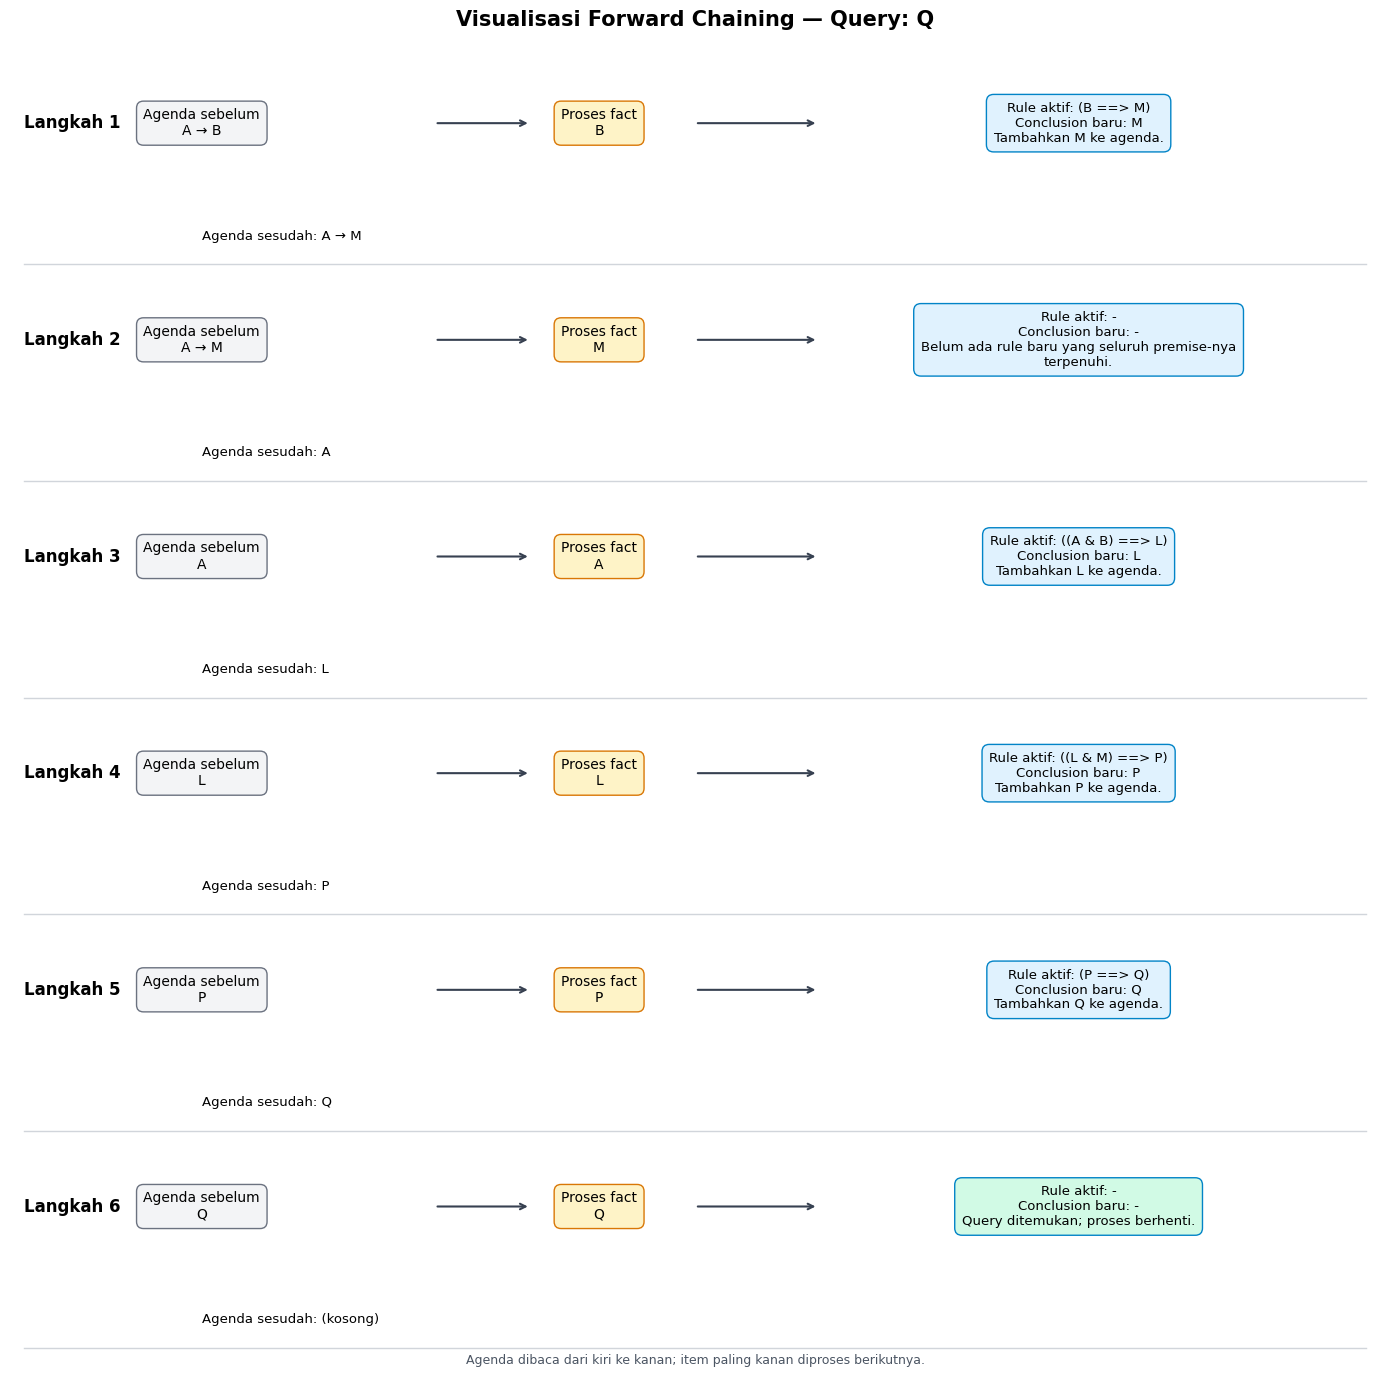

In [9]:
visualize_forward(trace_fc)


Pemanggilan forward chaining selalu memakai pola berikut:

```python
hasil, trace = ask_forward(kb, query)
```

`hasil` berisi `True` atau `False`. Setiap baris `trace` menyimpan satu langkah:

- **agenda sebelum**: isi agenda sebelum satu fact diambil;
- **fact diproses**: fact yang sedang dipakai untuk memperbarui rule;
- **rule aktif**: rule yang seluruh premise-nya baru saja terpenuhi;
- **conclusion baru**: conclusion yang baru ditambahkan ke agenda;
- **agenda sesudah**: isi agenda setelah keputusan dibuat;
- **keputusan**: alasan algoritma melanjutkan atau menghentikan proses.

Agenda memakai pola stack melalui `pop()`. Item paling kanan diproses lebih dulu.
`ask_forward` juga menghindari penambahan ulang conclusion yang sudah diketahui.


Trace menunjukkan bahwa fact awal diproses terlebih dahulu. Rule `B ==> M`
menghasilkan `M`. Setelah `A` dan `B` tersedia, rule `(A & B) ==> L`
menghasilkan `L`. Selanjutnya, `L` dan `M` menghasilkan `P`, lalu `P`
menghasilkan query `Q`.

Visualisasi di atas membaca proses sebagai rangkaian keputusan:

```text
lihat agenda → ambil fact → periksa rule → tambahkan conclusion → perbarui agenda
```

Urutan dapat berubah jika urutan isi agenda berubah. Namun, selama algoritma
dijalankan dengan benar, hasil akhirnya tetap sama. Langkah terakhir berwarna
hijau karena query sudah ditemukan dan proses berhenti.


---
# 4.4 Backward Chaining

## Penjelasan

**Backward chaining** adalah metode theorem proving yang bersifat
**goal-driven**. Proses dimulai dari query, bukan dari seluruh fact di dalam KB.
Algoritma mencari rule yang conclusion-nya sama dengan query, lalu menjadikan
setiap premise rule tersebut sebagai **subgoal** baru.

Contoh alurnya:

```text
Query Q ingin dibuktikan
        ↓
Cari rule dengan conclusion Q
        ↓
Ditemukan P ==> Q
        ↓
P menjadi subgoal
        ↓
Cari fact atau rule yang dapat membuktikan P
```

Untuk membuktikan sebuah goal:

1. jika goal sudah merupakan fact, goal berhasil;
2. jika belum, cari rule yang conclusion-nya sama dengan goal;
3. buktikan seluruh premise pada rule sebagai subgoal;
4. goal berhasil jika seluruh premise berhasil dibuktikan.

Pada KB sederhana di notebook ini, setiap goal mempunyai jalur rule yang jelas.
Hubungan beberapa premise dalam satu rule bersifat **AND**: seluruh premise
harus berhasil. Misalnya, `(L & M) ==> P` hanya dapat membuktikan `P` jika `L`
dan `M` sama-sama berhasil dibuktikan.

Trace backward chaining mencatat:

- **goal** yang sedang dibuktikan;
- **parent** atau goal yang meminta subgoal tersebut;
- **depth** atau kedalaman pada proof-search tree;
- rule yang diperiksa dan rule yang berhasil;
- keputusan dan hasil setiap goal.

Fungsi `ask_backward` sudah dibuat setelah Setup. Mahasiswa tidak perlu menulis
ulang algoritmanya. Masukkan `kb` dan `query`, lalu terima `hasil` dan `trace`.

| Aspek | Forward chaining | Backward chaining |
|---|---|---|
| Titik awal | Fact | Query |
| Arah | Fact menuju query | Query menuju fact |
| Strategi | Data-driven | Goal-driven |
| Bentuk visualisasi | Urutan perubahan agenda | Proof-search tree |
| Cocok untuk | Mengikuti consequence dari fact | Membuktikan satu query tertentu |

## Contoh penerapan

Gunakan KB dan query yang sama agar perbedaan arah pencariannya terlihat. Tabel
menunjukkan data setiap goal, sedangkan visualisasi memperlihatkan hubungan goal
dan subgoal sebagai proof-search tree.


In [10]:
# Use the same knowledge base and query as forward chaining.
found_bc, trace_bc = ask_backward(kb, query)

print("Pertanyaan          :", query)
print("Berhasil dibuktikan?:", found_bc)
trace_bc


Pertanyaan          : Q
Berhasil dibuktikan?: True


,langkah,parent,depth,goal,rule diperiksa,rule berhasil,keputusan,hasil
0,1,-,0,Q,(P ==> Q),(P ==> Q),Semua premise pada rule berhasil dibuktikan.,True
1,2,1,1,P,((L & M) ==> P),((L & M) ==> P),Semua premise pada rule berhasil dibuktikan.,True
2,3,2,2,L,((A & B) ==> L),((A & B) ==> L),Semua premise pada rule berhasil dibuktikan.,True
3,4,3,3,A,-,-,Goal sudah tersedia sebagai fact.,True
4,5,3,3,B,-,-,Goal sudah tersedia sebagai fact.,True
5,6,2,2,M,(B ==> M),(B ==> M),Semua premise pada rule berhasil dibuktikan.,True
6,7,6,3,B,-,-,Goal sudah tersedia sebagai fact.,True


### Visualisasi proof-search tree

Visualisasi berikut membaca trace sebagai tree:

- node paling atas adalah query;
- node di bawahnya adalah subgoal;
- garis menghubungkan parent goal dengan subgoal;
- node hijau berarti goal berhasil dibuktikan;
- node merah berarti goal tidak berhasil dibuktikan.

Urutan `Langkah` menunjukkan urutan pemeriksaan dari query menuju fact.


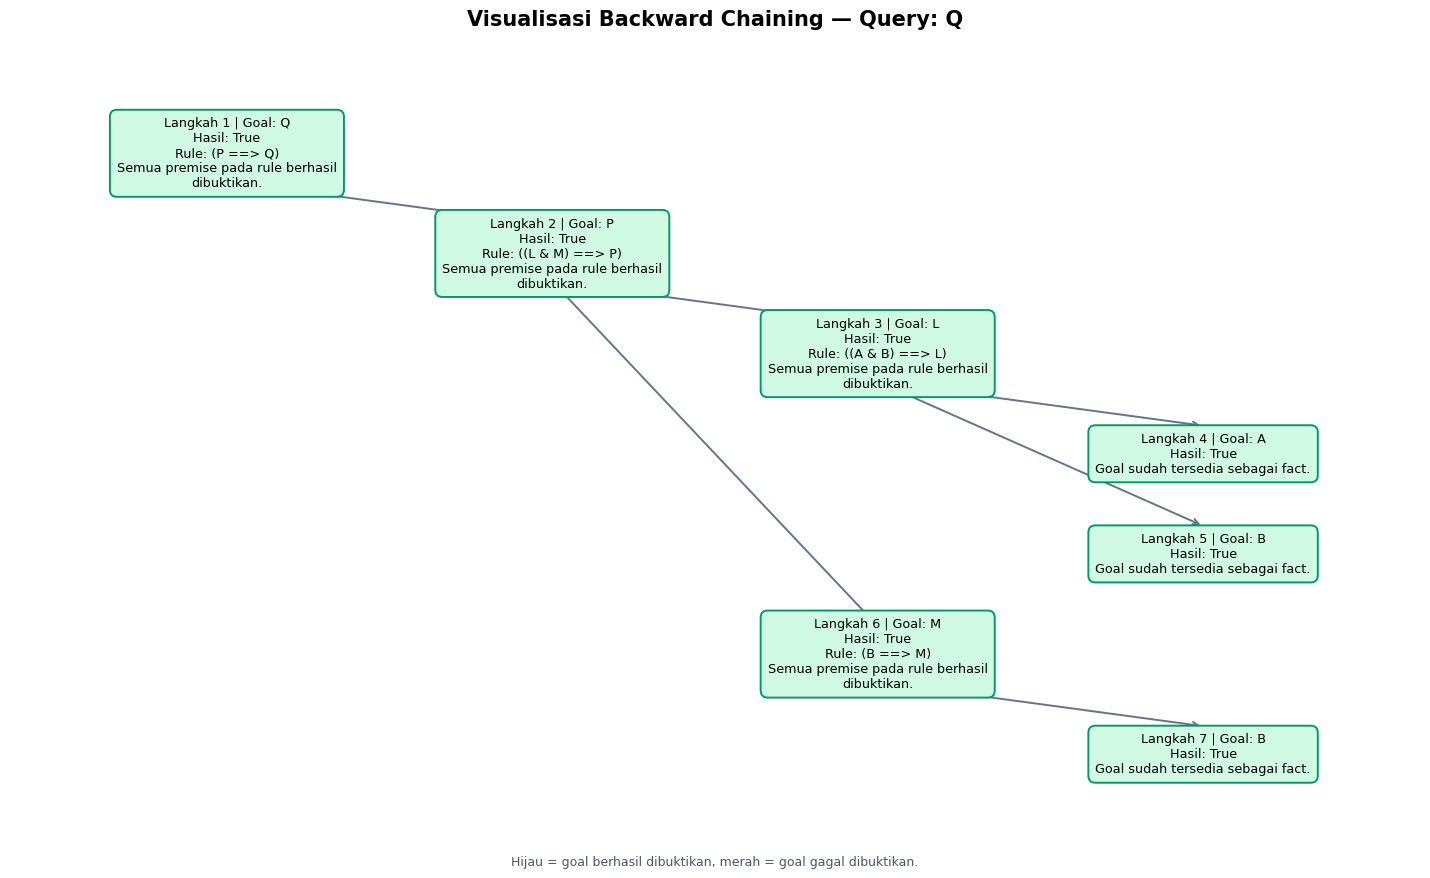

In [11]:
visualize_backward(trace_bc)


---
# Latihan Soal

Gunakan satu kasus yang sama untuk Soal 1-3. Tujuannya agar terlihat bahwa
forward chaining dan backward chaining dapat memakai KB Horn clause yang sama,
tetapi memulai pembuktian dari arah yang berbeda.

## Soal 1 — Membuat KB Horn Clause

Diketahui informasi berikut:

1. `A`, `B`, dan `C` adalah fact;
2. jika `A` dan `B` benar, maka `D` benar;
3. jika `B` dan `C` benar, maka `E` benar;
4. jika `D` dan `E` benar, maka `F` benar;
5. jika `F` benar, maka `G` benar.

Buat KB dengan panduan berikut:

1. tulis fact sebagai list string bernama `exercise_facts`;
2. ubah setiap kalimat "jika ... maka ..." menjadi rule dengan simbol `==>`;
3. gunakan `&` jika sebuah rule mempunyai lebih dari satu premise;
4. pastikan setiap rule mempunyai tepat satu conclusion;
5. buat `exercise_kb` dengan `make_kb(exercise_facts, exercise_rules)`;
6. tampilkan `exercise_kb.clauses` dan periksa apakah seluruh fact dan rule sudah
   masuk ke KB.

Tuliskan juga premise dan conclusion dari setiap rule yang dibuat.


<details>
<summary>Klik untuk melihat pembahasan</summary>

```python
exercise_facts = ["A", "B", "C"]

exercise_rules = [
    "(A & B) ==> D",
    "(B & C) ==> E",
    "(D & E) ==> F",
    "F ==> G",
]

exercise_kb = make_kb(exercise_facts, exercise_rules)
exercise_kb.clauses
```

Isi KB tersebut terdiri dari:

| Rule | Premise | Conclusion |
|---|---|---|
| `(A & B) ==> D` | `A`, `B` | `D` |
| `(B & C) ==> E` | `B`, `C` | `E` |
| `(D & E) ==> F` | `D`, `E` | `F` |
| `F ==> G` | `F` | `G` |

Semua rule merupakan definite clause karena mempunyai satu conclusion positif.

</details>


## Soal 2 — Pembuktian dengan Forward Chaining

Gunakan `exercise_kb` dari Soal 1 untuk membuktikan query `G` dengan forward
chaining. Mahasiswa cukup memanggil fungsi yang sudah dibuat setelah Setup:

```python
found_fc_exercise, trace_fc_exercise = ask_forward(exercise_kb, "G")
```

Kerjakan langkah berikut:

1. tampilkan nilai `found_fc_exercise`;
2. tampilkan tabel `trace_fc_exercise`;
3. tampilkan visualisasi keputusan dengan
   `visualize_forward(trace_fc_exercise)`;
4. tuliskan urutan fact yang diproses;
5. tuliskan rule yang menghasilkan `D`, `E`, `F`, dan `G`;
6. simpulkan apakah `KB ⊨ G`.


<details>
<summary>Klik untuk melihat pembahasan</summary>

```python
found_fc_exercise, trace_fc_exercise = ask_forward(exercise_kb, "G")

print("G berhasil dibuktikan?", found_fc_exercise)
display(trace_fc_exercise)
visualize_forward(trace_fc_exercise)
```

Hasilnya `True`. Dengan urutan agenda pada fungsi, fact yang diproses adalah:

```text
C → B → E → A → D → F → G
```

Pembuktiannya:

```text
A dan B menghasilkan D
B dan C menghasilkan E
D dan E menghasilkan F
F menghasilkan G
```

Karena query `G` berhasil diturunkan dari fact dan rule di dalam KB, maka
$KB \vDash G$.

</details>


## Soal 3 — Pembuktian dengan Backward Chaining

Gunakan `exercise_kb` dari Soal 1 dan query yang sama, yaitu `G`. Jalankan
backward chaining dengan fungsi yang sudah dibuat setelah Setup:

```python
found_bc_exercise, trace_bc_exercise = ask_backward(exercise_kb, "G")
```

Kerjakan langkah berikut:

1. tampilkan nilai `found_bc_exercise`;
2. tampilkan tabel `trace_bc_exercise`;
3. tampilkan proof-search tree dengan
   `visualize_backward(trace_bc_exercise)`;
4. tentukan root, subgoal, dan leaf fact pada tree;
5. jelaskan pembuktian dari query `G` sampai mencapai fact `A`, `B`, dan `C`;
6. simpulkan apakah `KB \vDash G`.


<details>
<summary>Klik untuk melihat pembahasan</summary>

```python
found_bc_exercise, trace_bc_exercise = ask_backward(exercise_kb, "G")

print("G berhasil dibuktikan?", found_bc_exercise)
display(trace_bc_exercise)
visualize_backward(trace_bc_exercise)
```

Hasilnya `True`. Backward chaining memulai pencarian dari query `G`:

```text
G
└── membutuhkan F
    ├── membutuhkan D
    │   ├── A adalah fact
    │   └── B adalah fact
    └── membutuhkan E
        ├── B adalah fact
        └── C adalah fact
```

- **root** pada tree adalah `G`;
- **subgoal** adalah `F`, `D`, dan `E`;
- **leaf fact** adalah `A`, `B`, dan `C`.

Karena seluruh leaf yang diperlukan tersedia sebagai fact, `D` dan `E`
berhasil dibuktikan. Keduanya membuktikan `F`, lalu `F` membuktikan `G`.
Dengan demikian, $KB \vDash G$.

</details>
